# Phase 6 — Transfer Learning: Partial Fine-Tuning

Goal: unfreeze `layer4` -- the last of ResNet50's four residual blocks -- on top of
Phase 5's frozen-backbone starting point, and fine-tune it alongside a fresh
classifier head. `layer1`-`layer3` stay frozen (generic low-level features: edges,
textures), so only `layer4`'s higher-level features and the head adapt to this
dataset. Same fixed split and the exact Phase 3 harness (`src/training/`),
unmodified, as every other phase.

Uses a **discriminative learning rate**: the head trains at `lr=1e-3` (same as
Phase 5), `layer4` at `lr=1e-4` (10x lower) -- `layer4` already holds useful
pretrained features, and a large gradient from an untrained, randomly-initialized
head early in training would otherwise risk overwriting them before the head has
learned anything useful to backpropagate.

**Status:** Done. Trained on Colab T4 GPU -- test accuracy 99.68%, test macro-F1
99.36%, the best result of any phase so far. See the takeaways at the bottom, and
`PHASES.md`, for the full writeup and comparison against Phase 4/5.

In [1]:
# Colab only: clone (or pull) the GitHub repo and cd into it. Safe to run locally
# too -- the import fails there and this cell is skipped. Repo is public, so a
# plain anonymous HTTPS clone works, no credentials needed.
try:
    import google.colab
    import os
    import shutil

    REPO_URL = "https://github.com/diljithG3/plant-disease-classification.git"
    REPO_DIR = "/content/plant-disease-classification"

    if os.path.isdir(os.path.join(REPO_DIR, ".git")):
        # A real repo from an earlier successful clone this session -- update it.
        _git_output = !git -C {REPO_DIR} pull 2>&1
    else:
        # No valid repo here yet -- possibly nothing, possibly a stray leftover
        # directory from an earlier failed attempt this session. Either way, wipe
        # it before cloning fresh: `git clone` refuses to write into a non-empty
        # directory, and re-running this cell after a failed first attempt would
        # otherwise silently take the `pull` branch above against a directory that
        # was never a real git repo, failing with "not a git repository".
        shutil.rmtree(REPO_DIR, ignore_errors=True)
        _git_output = !git clone {REPO_URL} {REPO_DIR} 2>&1

    ok = os.path.isdir(os.path.join(REPO_DIR, ".git"))
    if not ok:
        print("git clone/pull failed:")
        print("\n".join(_git_output))
        raise RuntimeError("git clone/pull failed -- see output above.")

    # os.chdir, not the %cd magic -- %cd does not reliably substitute a Python
    # variable in {}, so it was cd-ing into a literal "{REPO_DIR}" path and
    # silently failing, leaving cwd at /content.
    os.chdir(REPO_DIR)
    print("Repo ready. cwd:", os.getcwd())
except ImportError:
    pass

Repo ready. cwd: /content/plant-disease-classification


In [2]:
import sys, os

# Walk up from cwd to the project root (marked by configs/config.yaml) and put it on
# sys.path. Plain os.getcwd() is not reliable here -- it depends on how the kernel was
# launched (VS Code's Jupyter extension defaults to the notebook's own folder, not the
# project root).
_root = os.getcwd()
while not os.path.exists(os.path.join(_root, "configs", "config.yaml")):
    _parent = os.path.dirname(_root)
    if _parent == _root:
        raise RuntimeError("Could not find project root (configs/config.yaml) above " + os.getcwd())
    _root = _parent
sys.path.append(_root)

from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn

from src.utils.config import load_config
from src.utils.seed import seed_everything
from src.utils.device import get_device
from src.data import splits, transforms as T, dataset as D
from src.data.fetch_data import fetch_dataset
from src.models.transfer import build_resnet50_partial_finetune
from src.training.trainer import train_model
from src.training.checkpoint import load_checkpoint
from src.training import engine
from src.training.metrics import plot_confusion_matrix

cfg = load_config()
seed_everything(cfg["seed"])
device = get_device(cfg["training"]["device"])
print("Environment:", cfg["env"], "| Device:", device)

fetch_dataset(cfg)  # no-op if already downloaded

Environment: colab | Device: cuda
Cloning https://github.com/spMohanty/PlantVillage-Dataset.git (sparse checkout: raw/color only) ...
Done. 38 class folders at /content/dataset/PlantVillage/color


PosixPath('/content/dataset/PlantVillage/color')

## 1. Load Phase 2's fixed split

Reuses the split and `class_to_idx` cached by `02_data_pipeline.ipynb` unchanged --
same requirement as every previous phase: recomputing a split here would break
comparability with every other phase (`CLAUDE.md`).

In [3]:
DATA_PATH = cfg["data"]["path"]
ARTIFACTS_DIR = cfg["data"]["artifacts_dir"]

splits_path = Path(ARTIFACTS_DIR) / "splits.csv"
class_to_idx_path = Path(ARTIFACTS_DIR) / "class_to_idx.json"

if not splits_path.exists() or not class_to_idx_path.exists():
    raise FileNotFoundError(
        f"{splits_path} or {class_to_idx_path} missing -- run notebooks/02_data_pipeline.ipynb first."
    )

splits_df = pd.read_csv(splits_path)
class_to_idx = splits.build_class_to_idx(DATA_PATH, cache_path=str(class_to_idx_path))
idx_to_class = {v: k for k, v in class_to_idx.items()}
num_classes = len(class_to_idx)

print(f"Loaded split: {len(splits_df)} images, {num_classes} classes")
splits_df["split"].value_counts()

Loaded split: 54305 images, 38 classes


,count
split,
train,38012
test,8147
val,8146


## 2. Dataloaders -- full dataset

Same fixed split, same transforms as every other phase. Meant to run on Colab GPU --
local is CPU-only, fine for the cells above but not for a real training run.

In [4]:
train_transform = T.get_train_transforms(cfg)
eval_transform = T.get_eval_transforms(cfg)

loaders = D.make_dataloaders(
    splits_df,
    class_to_idx,
    train_transform,
    eval_transform,
    batch_size=cfg["dataloader"]["batch_size"],
    num_workers=cfg["dataloader"]["num_workers"],
    data_path=DATA_PATH,
)

for split, loader in loaders.items():
    print(f"{split}: {len(loader.dataset)} images, {len(loader)} batches")

train: 38012 images, 1188 batches
val: 8146 images, 255 batches
test: 8147 images, 255 batches


## 3. Model, loss, optimizer

`build_resnet50_partial_finetune` (`src/models/transfer.py`): same ResNet50 as
Phase 5, but `layer4` is left trainable alongside the fresh `fc` head --
`layer1`-`layer3` stay frozen.

Loss is unweighted `CrossEntropyLoss`, matching Phase 4 and Phase 5's choice, so any
accuracy/macro-F1 difference reflects the model/training change, not a different
imbalance-handling strategy. The optimizer uses two parameter groups with a
discriminative learning rate: `fc` at `1e-3` (same as Phase 5), `layer4` at `1e-4`
(10x lower) so its already-useful pretrained features aren't overwritten by large
early gradients from the still-untrained head.

In [5]:
model = build_resnet50_partial_finetune(num_classes).to(device)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,} total (layer4 + fc trainable, layer1-3 frozen)")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam([
    {"params": model.fc.parameters(), "lr": 1e-3},
    {"params": model.layer4.parameters(), "lr": 1e-4},
])

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s]


Trainable parameters: 15,042,598 / 23,585,894 total (layer4 + fc trainable, layer1-3 frozen)


## 4. Train

`max_epochs=30` and `early_stopping_patience: 7` on `macro_f1`
(`configs/config.yaml`) -- identical settings to every Phase 4/5 run, so only the
model and optimizer's learning-rate structure differ. Note: the logged `lr` column
in the training history below reflects only the first param group (`fc`)'s
learning rate, not `layer4`'s -- `src/training/trainer.py` logs
`optimizer.param_groups[0]["lr"]`.

In [6]:
checkpoints_dir = Path(cfg["logging"]["checkpoints_dir"]) / "phase6_resnet50_partial_finetune"
resume_path = checkpoints_dir / "last.pt"
if resume_path.exists():
    print(f"Found checkpoint from an earlier attempt, resuming from {resume_path}")

history = train_model(
    model, loaders, criterion, optimizer, device,
    run_name="phase6_resnet50_partial_finetune", cfg=cfg, class_to_idx=class_to_idx, max_epochs=30,
    resume_from=resume_path if resume_path.exists() else None,
)
pd.DataFrame(history)

train:   0%|          | 0/1188 [00:00<?, ?it/s]

eval:   0%|          | 0/255 [00:00<?, ?it/s]

Epoch 0: train_loss=0.2445 val_loss=0.0441 val_acc=0.9845 val_macro_f1=0.9780 (250.5s)


train:   0%|          | 0/1188 [00:00<?, ?it/s]

eval:   0%|          | 0/255 [00:00<?, ?it/s]

...

train:   0%|          | 0/1188 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c976c448a40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c976c448a40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

eval:   0%|          | 0/255 [00:00<?, ?it/s]

Epoch 24: train_loss=0.0043 val_loss=0.0064 val_acc=0.9977 val_macro_f1=0.9972 (258.3s)
Early stopping at epoch 24 (no macro_f1 improvement for 7 epochs)


,epoch,train_loss,val_loss,val_accuracy,val_macro_f1,lr,epoch_time_sec
0,0,0.244482,0.044101,0.984532,0.978007,0.001,250.511279
1,1,0.047528,0.030148,0.991161,0.987590,0.001,256.867774
2,2,0.027185,0.022756,0.991775,0.987661,0.001,257.722060
3,3,0.022026,0.023534,0.992021,0.989013,0.001,265.838771
4,4,0.018880,0.014916,0.994353,0.991967,0.001,257.329639
5,5,0.013772,0.025886,0.991161,0.987404,0.001,261.370551
6,6,0.011929,0.013293,0.995335,0.992549,0.001,262.158494
7,7,0.009199,0.011844,0.996072,0.994405,0.001,254.076119
8,8,0.009254,0.017389,0.994599,0.991343,0.001,261.105146
9,9,0.008699,0.010652,0.995458,0.993144,0.001,254.827219


## 5. Verify checkpoint round-trip, then evaluate on the held-out test set

Same round-trip check as every previous phase: confirm `best.pt` reloads into a
**fresh** model instance and reproduces the metric it was saved with -- then use
that reloaded model for the real held-out test-set evaluation (not the val set used
during training/early stopping, which already influenced checkpoint selection).

In [7]:
checkpoints_dir = Path(cfg["logging"]["checkpoints_dir"]) / "phase6_resnet50_partial_finetune"
best_path = checkpoints_dir / "best.pt"
assert best_path.exists()

fresh_model = build_resnet50_partial_finetune(num_classes).to(device)
payload = load_checkpoint(best_path, fresh_model, optimizer=None, map_location=device)
assert payload["class_to_idx"] == class_to_idx, "class_to_idx did not round-trip!"
print(f"Reloaded checkpoint from epoch {payload['epoch']}, best val {cfg['training']['checkpoint_metric']}={payload['best_metric']:.4f}")

test_metrics = engine.evaluate(fresh_model, loaders["test"], criterion, device, num_classes)
print(f"Test accuracy: {test_metrics['accuracy']:.4f} | Test macro_f1: {test_metrics['macro_f1']:.4f}")

Reloaded checkpoint from epoch 17, best val macro_f1=0.9974


eval:   0%|          | 0/255 [00:00<?, ?it/s]

Test accuracy: 0.9968 | Test macro_f1: 0.9936


## 6. Confusion matrix (test set)

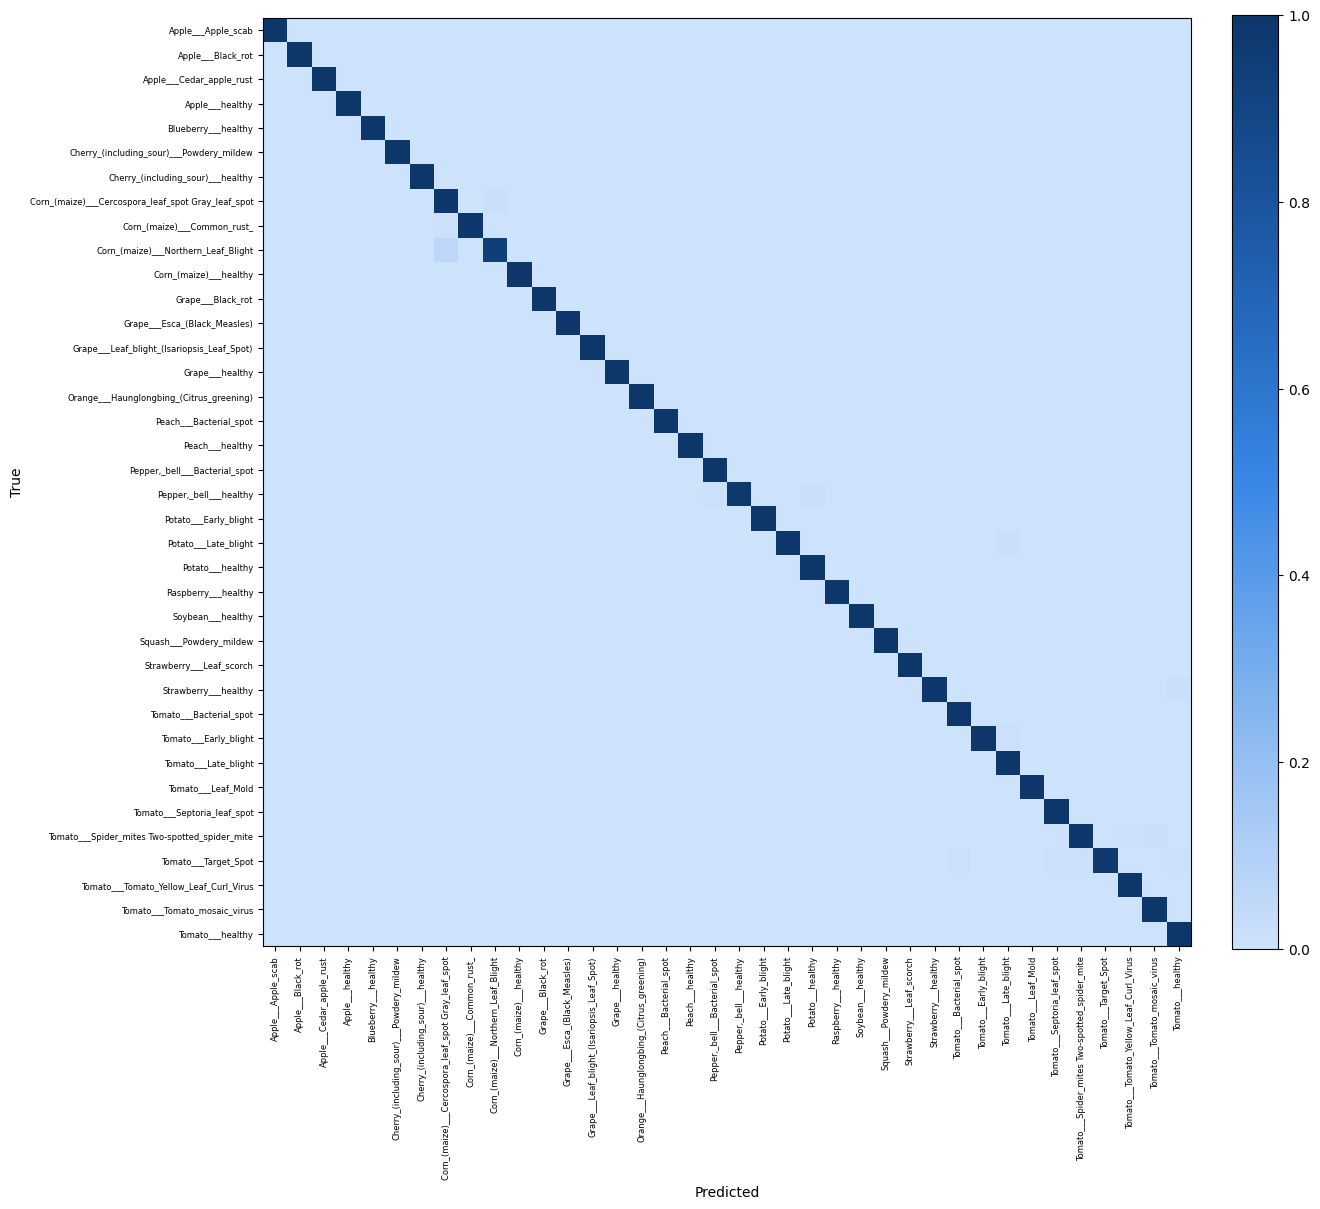

In [8]:
class_names = [idx_to_class[i] for i in range(num_classes)]
plot_confusion_matrix(test_metrics["confusion_matrix"], class_names)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()

## 7. Per-class recall vs. train-set frequency

Same check every previous phase ran: does the 36x class imbalance show up in which
classes this model struggles with, and does `Tomato___Early_blight` -- the chronic
weak class across Phase 4 and Phase 5 -- improve now that `layer4` can adapt
directly to this dataset's textures instead of relying on frozen, generic ImageNet
features?

In [9]:
recall_series = pd.Series(
    test_metrics["per_class_recall"], index=[idx_to_class[i] for i in range(num_classes)]
).sort_values()

train_counts = splits_df[splits_df["split"] == "train"]["class"].value_counts()
comparison = pd.DataFrame({"train_count": train_counts, "test_recall": recall_series}).sort_values("train_count")

print("Lowest test recall (worst-performing classes):")
print(recall_series.head(10))
comparison

Lowest test recall (worst-performing classes):
Corn_(maize)___Northern_Leaf_Blight                   0.938776
Tomato___Target_Spot                                  0.980952
Pepper,_bell___healthy                                0.981900
Strawberry___healthy                                  0.985507
Potato___Late_blight                                  0.986667
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot    0.987013
Tomato___Spider_mites Two-spotted_spider_mite         0.988095
Tomato___Early_blight                                 0.993333
Corn_(maize)___Common_rust_                           0.994413
Cherry_(including_sour)___Powdery_mildew              1.000000
dtype: float64


,train_count,test_recall
Potato___healthy,106,1.000000
Apple___Cedar_apple_rust,192,1.000000
Peach___healthy,252,1.000000
Raspberry___healthy,260,1.000000
Tomato___Tomato_mosaic_virus,261,1.000000
Grape___healthy,296,1.000000
Strawberry___healthy,319,0.985507
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,359,0.987013
Apple___Black_rot,435,1.000000
Apple___Apple_scab,441,1.000000


## Summary & implications for Phase 7

In [10]:
print(f"Partial fine-tune test accuracy: {test_metrics['accuracy']:.4f}")
print(f"Partial fine-tune test macro_f1: {test_metrics['macro_f1']:.4f}")
print(f"Worst-recall class: {recall_series.index[0]} (recall={recall_series.iloc[0]:.3f}, train_count={int(train_counts.get(recall_series.index[0], 0))})")
print(f"Best-recall class: {recall_series.index[-1]} (recall={recall_series.iloc[-1]:.3f})")

Partial fine-tune test accuracy: 0.9968
Partial fine-tune test macro_f1: 0.9936
Worst-recall class: Corn_(maize)___Northern_Leaf_Blight (recall=0.939, train_count=690)
Best-recall class: Tomato___healthy (recall=1.000)


Takeaways:

- **Test accuracy 99.68%, test macro-F1 99.36%** -- the best result of any phase so
  far, beating even Phase 4's fully-iterated `SimpleCNNBatchNormDeep` (98.97% /
  98.46%). Best val macro-F1 0.9974 at epoch 17/30 -- **early stopping actually
  triggered this time** (epoch 24, exactly 7 non-improving epochs after epoch 17),
  the first phase where it did; Phase 4 and Phase 5 both ran the full 30-epoch
  ceiling. ~108 minutes total training time (T4 GPU, 25 epochs) -- faster overall
  than Phase 5's 138 minutes/30 epochs, simply because it converged and stopped
  sooner.
- **Beats every prior approach on both metrics:** vs. Phase 5 (frozen backbone,
  97.88% / 97.30%): +1.80pp / +2.06pp. vs. Phase 4's iterated CNN (98.97% /
  98.46%): +0.71pp / +0.90pp. A little targeted adaptation (`layer4`) on top of
  strong pretrained features beats both "frozen generic features" (Phase 5) and
  "everything learned from scratch" (Phase 4).
- **`Tomato___Early_blight` -- the chronic weak class in both Phase 4 and Phase 5
  -- is resolved.** Recall jumped to 0.993, no longer near the bottom of the
  per-class ranking. Unfreezing `layer4` let the network adapt its higher-level
  features to the specific textures distinguishing this disease, something Phase
  5's frozen generic ImageNet features apparently couldn't do.
- **A new worst class emerged instead: `Corn_(maize)___Northern_Leaf_Blight`**
  (recall 0.939, 690 train images) -- the same class Phase 4's BatchNorm iteration
  had damaged (0.946 -> 0.816) as a side effect of fixing a different class's
  confusion, before partially recovering in the deep variant (->0.918). This
  class's difficulty looks architecture-independent rather than tied to any one
  approach's specific weakness -- likely genuine visual similarity to
  `Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot`, a real property of the data
  Phase 8 should keep in mind.
- **Imbalance still doesn't predict difficulty:** `Potato___healthy` (the smallest
  class, 106 train images) reaches a perfect 1.000 recall.
- Next: Phase 7 (full fine-tuning) -- unfreeze the entire ResNet50 backbone, very
  low learning rate.

## Phase 6 complete

See `PHASES.md` for the full writeup. Next: Phase 7 (full fine-tuning).